Length of anomaly: 145
Length of co2: 145
Pearson correlation coefficient: 0.93
P-value: 6.44e-66


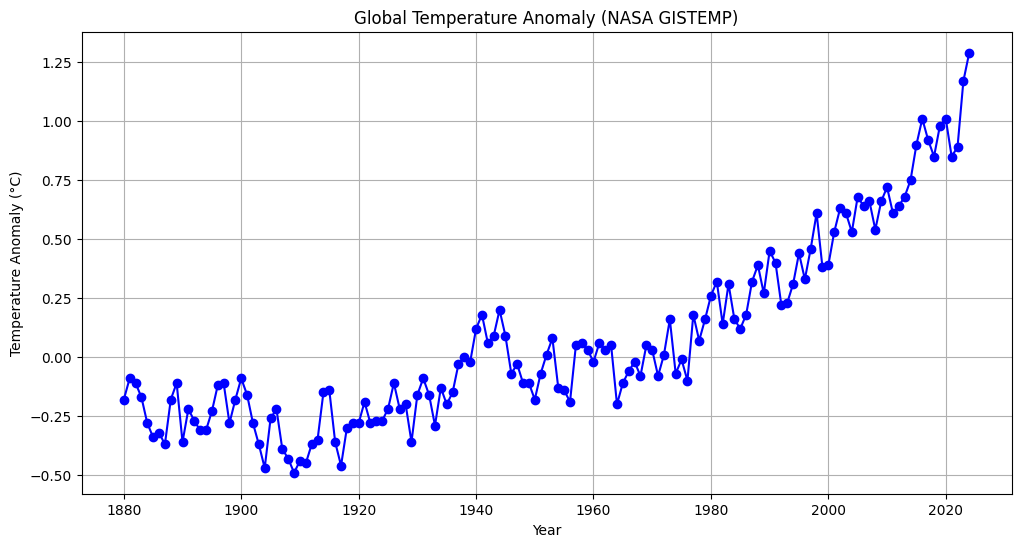

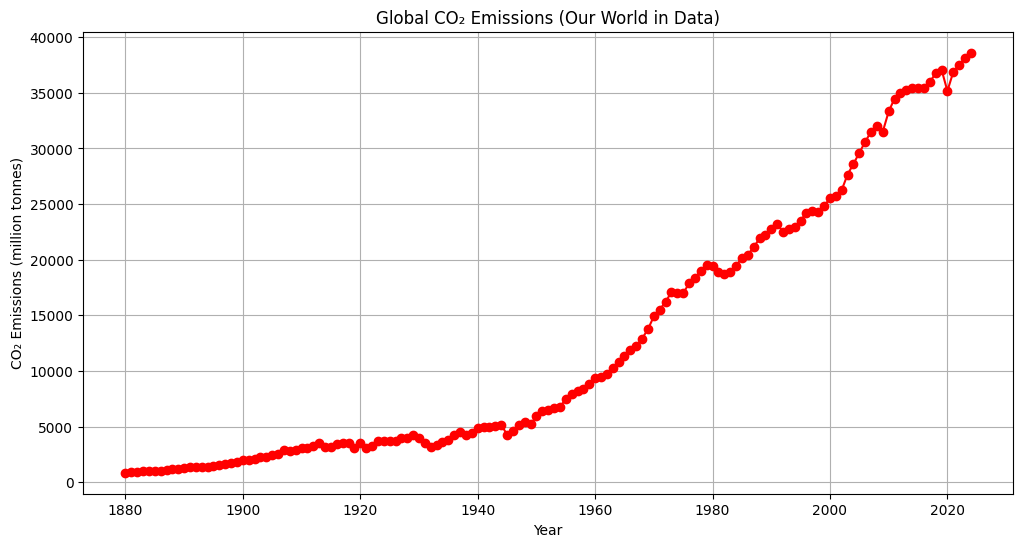

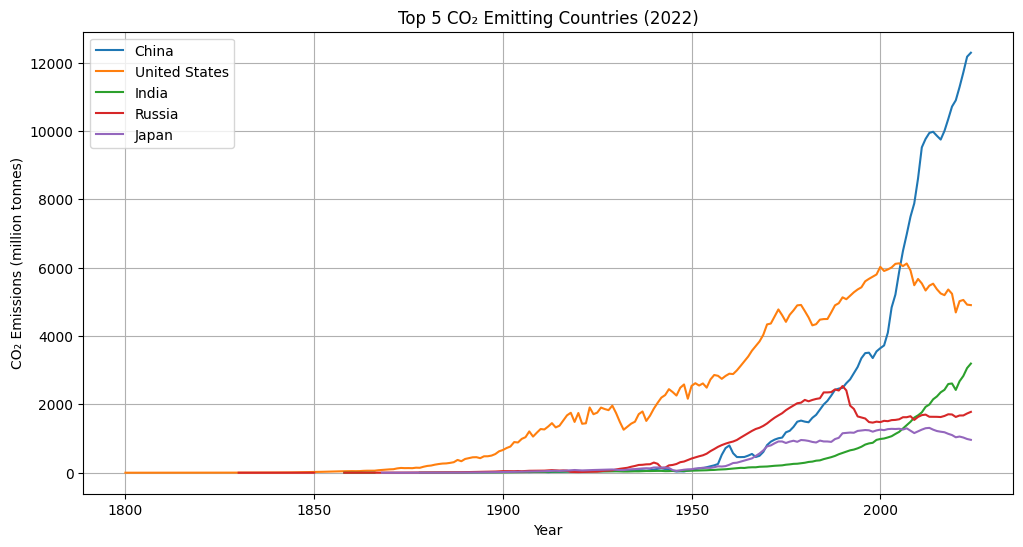

In [6]:
# Climate Change Analysis using Distributed PySpark (Hadoop ecosystem)
# This version uses expr() to safely execute try_cast without import version conflicts.

from pyspark.sql import SparkSession
from pyspark import SparkFiles
from pyspark.sql.functions import col, expr
import pandas as pd
import urllib.request
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import pearsonr

# Start an optimized Spark session for multi-core scaling
spark = SparkSession.builder \
    .appName("ClimateChangeAnalysis") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

# --- HEADER DETECTION LAYER ---
temp_url = 'https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv'
co2_url = 'https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv'

def find_header_skip(url):
    with urllib.request.urlopen(url) as response:
        for i, line in enumerate(response):
            decoded_line = line.decode('utf-8')
            if 'Year' in decoded_line or 'year' in decoded_line:
                return i
    return 0

temp_skip_rows = find_header_skip(temp_url)

# --- DISTRIBUTED DATA INGESTION LAYER ---
spark.sparkContext.addFile(temp_url)
spark.sparkContext.addFile(co2_url)

# Load datasets natively using discovered line configurations
df_temp_raw = spark.read.csv(
    SparkFiles.get("GLB.Ts+dSST.csv"),
    header=True,
    inferSchema=True,
    comment="="
)

# Fallback structure validation
if "Year" not in df_temp_raw.columns:
    pdf_temp_clean = pd.read_csv(temp_url, skiprows=temp_skip_rows)
    df_temp_raw = spark.createDataFrame(pdf_temp_clean)

df_co2_raw = spark.read.csv(SparkFiles.get("owid-co2-data.csv"), header=True, inferSchema=True)

# --- DISTRIBUTED TRANSFORMATION LAYER ---
# FIXED: Utilizing expr() to run try_cast natively in Spark SQL, safely handling '***'
df_temp = df_temp_raw.select(
    expr("try_cast(Year as int)").alias("year"),
    expr("try_cast(`J-D` as double)").alias("anomaly")
).dropna()

# Process global CO₂ emissions natively across partitions
df_co2 = df_co2_raw.filter(col("country") == "World").select(
    expr("try_cast(year as int)").alias("year"),
    expr("try_cast(co2 as double)").alias("co2")
).dropna()

# Execute cluster-optimized relational shuffle join
df_joined = df_temp.join(df_co2, on='year', how='inner')

# --- DOWNSAMPLING FOR METRICS & VISUALIZATION ---
# Bring only the light, transformed dataset back to the driver node
joined_pd = df_joined.toPandas()
anomaly = pd.to_numeric(joined_pd['anomaly'], errors='coerce')
co2 = pd.to_numeric(joined_pd['co2'], errors='coerce')
mask = anomaly.notna() & co2.notna()
anomaly = anomaly[mask]
co2 = co2[mask]

print("Length of anomaly:", len(anomaly))
print("Length of co2:", len(co2))

if len(anomaly) > 1 and len(co2) > 1:
    corr, p_value = pearsonr(anomaly, co2)
    print(f'Pearson correlation coefficient: {corr:.2f}')
    print(f'P-value: {p_value:.3g}')
else:
    print("Not enough data points to compute correlation.")

# Plot global temperature anomaly
plt.figure(figsize=(12,6))
plt.plot(joined_pd['year'], anomaly, marker='o', color='blue')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Global Temperature Anomaly (NASA GISTEMP)')
plt.grid(True)
plt.show()

# Plot global CO₂ emissions
plt.figure(figsize=(12,6))
plt.plot(joined_pd['year'], co2, marker='o', color='red')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions (million tonnes)')
plt.title('Global CO₂ Emissions (Our World in Data)')
plt.grid(True)
plt.show()

# Interactive plot
fig = px.line(joined_pd, x='year', y='co2', title='Global CO₂ Emissions (Interactive)')
fig.show()

# --- NATIVE SPARK COUNTRY RANKING ANALYSIS ---
year_filter = 2022
# Filter out regions/groups using non-null ISO codes and sort entirely in Spark
df_filtered_year = df_co2_raw.filter((col("year") == year_filter) & (col("iso_code").isNotNull()))
top_countries_df = df_filtered_year.orderBy(col("co2").desc()).limit(5)
top_countries = [row['country'] for row in top_countries_df.select("country").collect()]

# Push filtering logic to the cluster nodes before creating the plotting dataframe
df_top_pd = df_co2_raw.filter(col("country").isin(top_countries)).toPandas()

plt.figure(figsize=(12,6))
for country in top_countries:
    country_df = df_top_pd[df_top_pd['country'] == country]
    plt.plot(country_df['year'], country_df['co2'], label=country)
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions (million tonnes)')
plt.title(f'Top 5 CO₂ Emitting Countries ({year_filter})')
plt.legend()
plt.grid(True)
plt.show()

# Choropleth map data generation
df_map = df_co2_raw.filter(col("year") == year_filter).toPandas()
fig = px.choropleth(
    df_map,
    locations="iso_code",
    color="co2",
    hover_name="country",
    color_continuous_scale="Reds",
    title=f"CO₂ Emissions by Country ({year_filter})"
)
fig.show()

# Safely terminate the cluster session
spark.stop()